In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import yaml
from config import DAS_FILE
from DAS import DAS

with open("configs/denoising.yaml") as f:
    cfg = yaml.safe_load(f)

# Load sensor metadata; yaml values take priority over file metadata
_meta = DAS(DAS_FILE).meta
dx = cfg.get("dx") or _meta["dx"]
dt = cfg.get("dt") or _meta["dt"]

In [ ]:
import os
import numpy as np
import pandas as pd

import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

from models.unet import UNet
from preprocessing import make_preprocess
from dataset import DASSampleDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

DATA_DIR = cfg.get("data_dir", "data")
labels_path = os.path.join(DATA_DIR, cfg["labels_csv"])

FS_DAS = cfg["fs"]
DT = dt
DX = dx

df = pd.read_csv(labels_path)
df_pos = df[df["count"] > 0].copy()
df_pos = df_pos.sample(frac=1.0, random_state=42).reset_index(drop=True)

print("Total samples with count > 0:", len(df_pos))

N_TRAIN = min(cfg.get("n_train", 40), len(df_pos))
n_remaining = len(df_pos) - N_TRAIN
n_val = n_remaining // 2
n_test = n_remaining - n_val

train_df = df_pos.iloc[:N_TRAIN]
val_df   = df_pos.iloc[N_TRAIN:N_TRAIN + n_val]
test_df  = df_pos.iloc[N_TRAIN + n_val:]

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

In [5]:
test_df

,sample_id,data_path,count,start_frame,end_frame,vehicle_type
57,32,data/sample_000032.npy,1,2832,2983,van
58,108,data/sample_000108.npy,1,5111,5262,truck
59,79,data/sample_000079.npy,4,4242,4392,mixed
60,47,data/sample_000047.npy,4,3282,3433,mixed
61,29,data/sample_000029.npy,3,2742,2893,mixed
62,53,data/sample_000053.npy,2,3462,3613,mixed
63,83,data/sample_000083.npy,1,4361,4512,van
64,1,data/sample_000001.npy,4,1902,2053,mixed
65,67,data/sample_000067.npy,1,3882,4033,suv
66,21,data/sample_000021.npy,1,2502,2653,suv


In [6]:
from preprocessing import make_preprocess

# ---- Defaults (your values) ----
FS_DAS = 2000.0
DT = dt
DX = dx  # meters per channel

# ---- Choose your pipeline by editing STEPS ----
# Convention: ordered list of ("step_name", {params})
# Available steps: "detrend", "bandpass", "fk_filter", "curvelet"

detrend_step =     ("detrend", {
        "axis": 1,          # time axis (channels, time)
    })

curvelet_step =     ("curvelet", {
        "n_scales": 4,      # >=2
        "n_angles": 16,     # >=8
        "thresh": 2.5,      # 3..5 typical; higher => stronger shrinkage
        "keep_lowpass": False,
        "robust_mad": True
    })

STEPS = [
    # 1) Detrend (time-domain)
    ("detrend", {
        "axis": 1,          # time axis (channels, time)
    }),

    # 2) Bandpass (time-domain) - SOS Butterworth
    ("bandpass", {
        "f_lo": 0.5,        # Hz
        "f_hi": 30.0,        # Hz
        "order": 2,
        "axis": 1,          # time axis
        "zero_phase": True # True -> sosfiltfilt (zero-phase), False -> sosfilt (causal)
    }),

    # 3) f-k filter (frequency-wavenumber) - needs dx, dt
    ("fk_filter", {
        "fmin": None,        # Hz 
        "fmax": None,        # Hz
        "vmin": 10.0,      # m/s 
        "vmax": 60.0,     # m/s
        "taper": 0.05      # 0..~0.2 smooth ramp at bounds
    }),

    # Extract the envelope via Hilbert transform
    #("hilbert", {
    #    "axis": 1,
    #    "mode": "envelope"  # or "phase"
    #}),

    # 4) Curvelet-like directional denoise (frequency domain wedges)
    #("curvelet", {
    #    "n_scales": 4,      # >=2
    #    "n_angles": 16,     # >=8
    #    "thresh": 2.5,      # 3..5 typical; higher => stronger shrinkage
    #    "keep_lowpass": False,
    #    "robust_mad": True
    #}),
]

# Build preprocess callable: preprocess(x, fs, **ctx) -> y
# - dx captured here (used by fk_filter)
# - dt captured here; if you omit dt, it will default to 1/fs at call time
pp = make_preprocess(
    steps=STEPS,
    dx=DX,
    dt=DT,
)

# Usage:
# clean = pp(raw, FS_DAS)      # raw shape: (n_channels, n_time)


train_dataset = DASSampleDataset(train_df, preprocess=pp, fs_das=FS_DAS)
val_dataset   = DASSampleDataset(val_df,   preprocess=pp, fs_das=FS_DAS)
test_dataset  = DASSampleDataset(test_df,  preprocess=pp, fs_das=FS_DAS)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=2, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=2, shuffle=False)

print("Example batch shape:", next(iter(train_loader))[0].shape)

Example batch shape: torch.Size([2, 1, 34, 10000])


In [7]:
model = UNet(in_channels=1, out_channels=1).to(device)

criterion = nn.MSELoss()  # regression: raw -> clean
optimizer = optim.Adam(model.parameters(), lr=6e-6)

print(sum(p.numel() for p in model.parameters()), "trainable parameters")


1797409 trainable parameters


In [ ]:
# Load the trained model saved by: python train.py --task denoising
model.load_state_dict(torch.load("results/denoising/best_model.pt", map_location=device))
model.eval()
print("Model loaded from results/denoising/best_model.pt")

In [ ]:
from Utilities import plot_das_data
import matplotlib.pyplot as plt

if len(test_df) > 0:
    row = test_df.iloc[15]
else:
    row = train_df.iloc[15]

test_path = row["data_path"]
test_sid = f"sample_{row['sample_id']:06d}" if isinstance(row["sample_id"], (int, np.integer)) else str(row["sample_id"])

raw = np.load(test_path).astype(np.float32)
clean = pp(raw, FS_DAS).astype(np.float32)

model.eval()
with torch.no_grad():
    raw_t = torch.from_numpy(raw[None, None, ...]).to(device)
    pred = model(raw_t).squeeze().cpu().numpy()

channels = np.arange(raw.shape[0])
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

plot_das_data(data=raw,   channels=channels, dx=dx, dt=dt, title=f"{test_sid} - Raw",              ax=axes[0], fig=fig, show=False)
plot_das_data(data=clean, channels=channels, dx=dx, dt=dt, title=f"{test_sid} - Clean (Preprocess)", ax=axes[1], fig=fig, show=False)
plot_das_data(data=pred,  channels=channels, dx=dx, dt=dt, title=f"{test_sid} - UNet Output",       ax=axes[2], fig=fig, show=False)

plt.tight_layout()
plt.show()

In [ ]:
from Utilities import plot_das_data
import matplotlib.pyplot as plt

if len(test_df) > 0:
    row = test_df.iloc[7]
else:
    row = train_df.iloc[7]

test_path = row["data_path"]
test_sid = f"sample_{row['sample_id']:06d}" if isinstance(row["sample_id"], (int, np.integer)) else str(row["sample_id"])

raw = np.load(test_path).astype(np.float32)
clean = pp(raw, FS_DAS).astype(np.float32)

model.eval()
with torch.no_grad():
    raw_t = torch.from_numpy(raw[None, None, ...]).to(device)
    pred = model(raw_t).squeeze().cpu().numpy()

channels = np.arange(raw.shape[0])
plot_das_data(data=raw, channels=channels, dx=dx, dt=dt, title="", show=True)
plt.show()

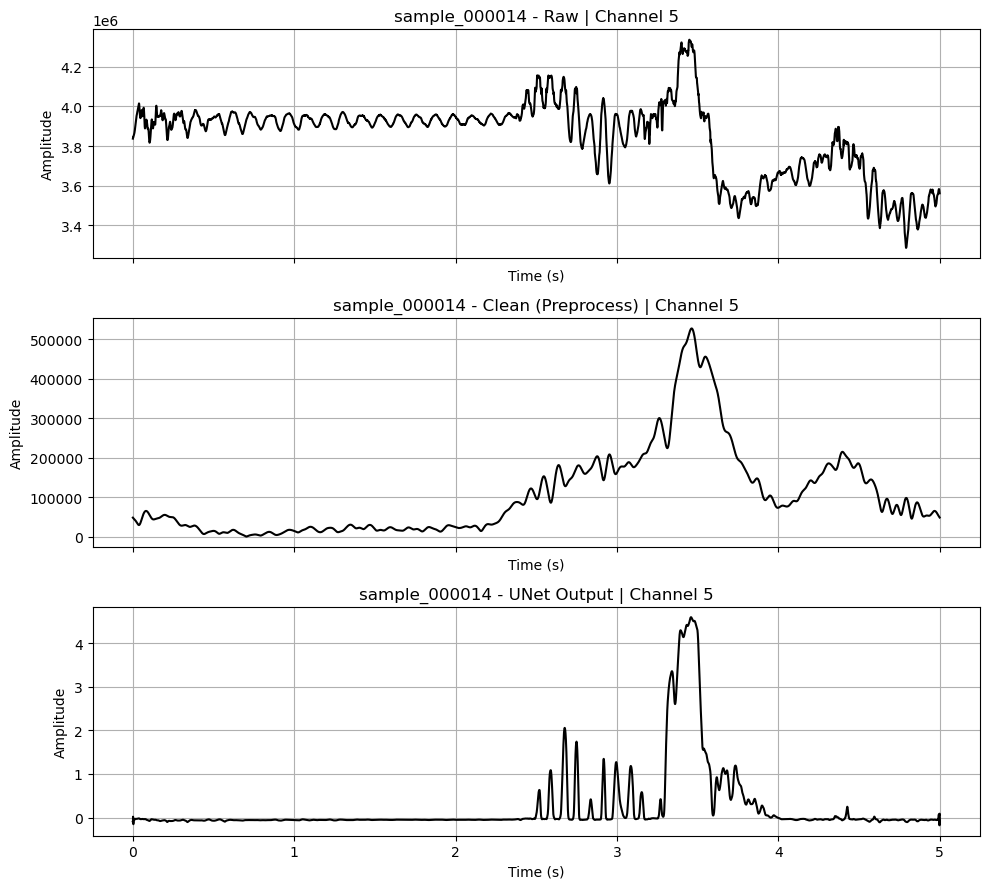

In [117]:
from Utilities import plot_single
import matplotlib.pyplot as plt

ch = 5          # channel to inspect
t0, t1 = 0, 5    # or e.g. 0.5, 1.5

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# ---- RAW ----
plot_single(
    data=raw,
    channel_num=ch,
    dx=dx,
    dt=dt,
    start_time=t0,
    end_time=t1,
    ax=axes[0],
    show=False,
)
axes[0].set_title(f"{test_sid} - Raw | Channel {ch}")

# ---- CLEAN ----
plot_single(
    data=clean,
    channel_num=ch,
    dx=dx,
    dt=dt,
    start_time=t0,
    end_time=t1,
    ax=axes[1],
    show=False,
)
axes[1].set_title(f"{test_sid} - Clean (Preprocess) | Channel {ch}")

# ---- UNET OUTPUT ----
plot_single(
    data=pred,
    channel_num=ch,
    dx=dx,
    dt=dt,
    start_time=t0,
    end_time=t1,
    ax=axes[2],
    show=False,
)
axes[2].set_title(f"{test_sid} - UNet Output | Channel {ch}")

plt.tight_layout()
plt.show()


In [ ]:
# Denoised samples are saved automatically by train.py (save_denoised: true in configs/denoising.yaml).
# To regenerate: python train.py --task denoising
print("Denoised samples are in data/denoised/ — run `python train.py --task denoising` to regenerate.")